# TTK7 Assignment 1: Analysis of a brainwave signal
> Authored by Sondre Tveiten and Hans G. L. Grayston

Main takeaway: The methods of analysis is limited due to the lack of IMF decomposition.


### Load the timeseries as a Pandas Dataframe type object

In [1]:
import pandas as pd
import numpy as np
from src.signal_analyzer import SignalAnalyzer

df = pd.read_csv('signals/Signal3_2018.csv', header=None)
base_signal = df.iloc[0].values
df_mask = pd.read_csv('signals/signal3_imf_new_final_signal.csv', header=None)
masked_signal = df_mask.iloc[0].values


## 

## The signal at hand

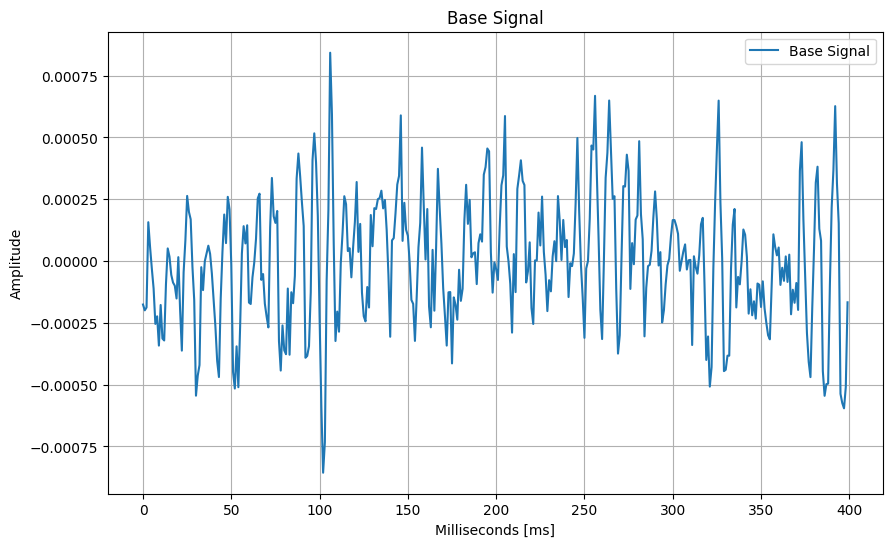

In [2]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(base_signal, label='Base Signal')
plt.title('Base Signal')
plt.xlabel('Milliseconds [ms]')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

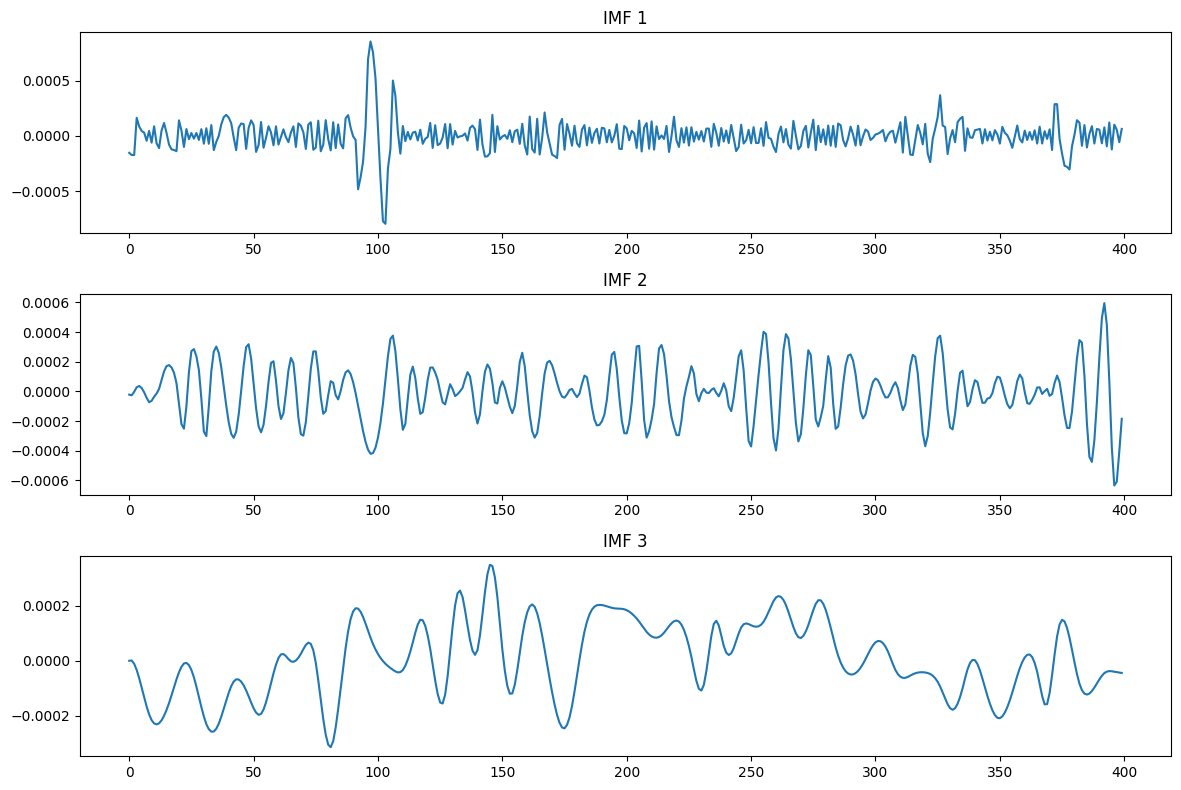

In [3]:
from PyEMD import EMD

# Perform EMD
emd = EMD(std_thr=1, total_power_thr=0.001)
imfs = emd(base_signal, max_imf=15)  # Extract up to 15 IMFs

# Check if only 3 IMFs are found
if imfs.shape[0] == 3:
    mid_frequency_imf = imfs[1]  # Extract the mid-frequency IMF (index 1)
    base_signal = mid_frequency_imf  # Declare it as the new base signal

# Plot the IMFs
plt.figure(figsize=(12, 8))
for i, imf in enumerate(imfs):
    plt.subplot(len(imfs), 1, i + 1)
    plt.plot(imf)
    plt.title(f'IMF {i + 1}')
plt.tight_layout()
plt.show()

### Performance Measure

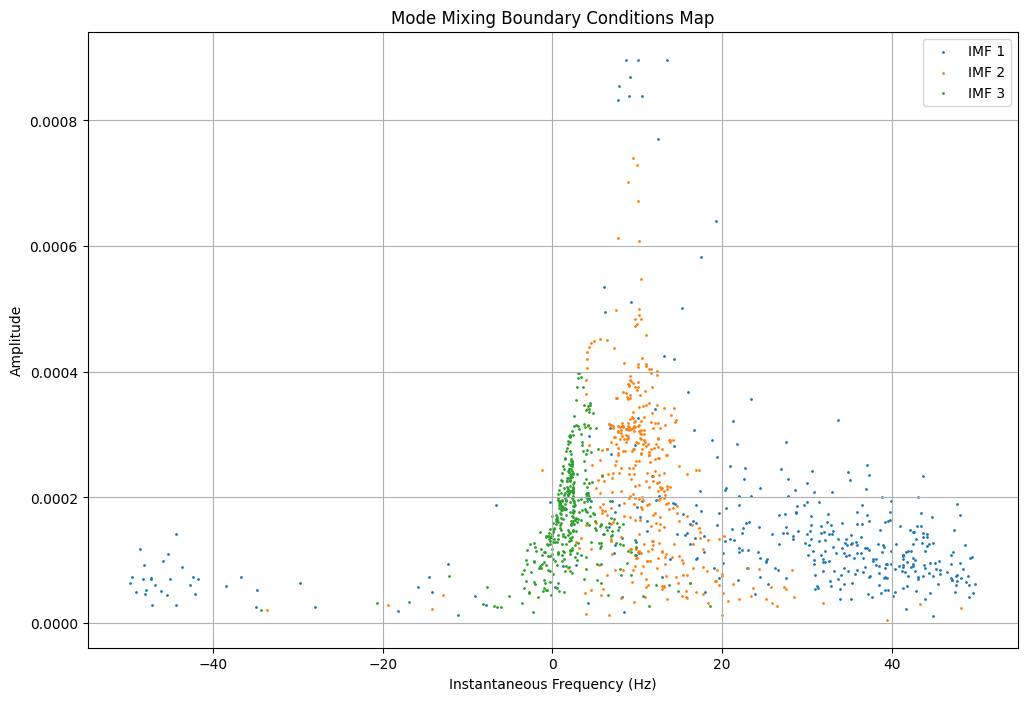

In [15]:
from scipy.signal import hilbert

# Calculate the instantaneous frequency and amplitude for each IMF
imf_amplitudes = []
imf_frequencies = []

for imf in imfs:
    analytic_signal = hilbert(imf)
    amplitude_envelope = np.abs(analytic_signal)
    instantaneous_phase = np.unwrap(np.angle(analytic_signal))
    instantaneous_frequency = np.diff(instantaneous_phase) / (2.0 * np.pi) * 100  # Assuming fs=100 Hz

    imf_amplitudes.append(amplitude_envelope[:-1])  # Exclude the last point to match frequency length
    imf_frequencies.append(instantaneous_frequency)

# Plot the mode mixing boundary conditions map
plt.figure(figsize=(12, 8))
for i, (amplitude, frequency) in enumerate(zip(imf_amplitudes, imf_frequencies)):
    plt.scatter(frequency, amplitude, s=1, label=f'IMF {i + 1}')

plt.title('Mode Mixing Boundary Conditions Map')
plt.xlabel('Instantaneous Frequency (Hz)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()
plt.show()

## Which analyses did we opt for?

The Hilbert transform proved to be uninformative for this signal, as there are several modes in the mix. HT expects a single-mode input only, **so we gain nothing on calculating it.** Otherwise, we opted for FFT, STFT, WVT and Wavelet Transform.


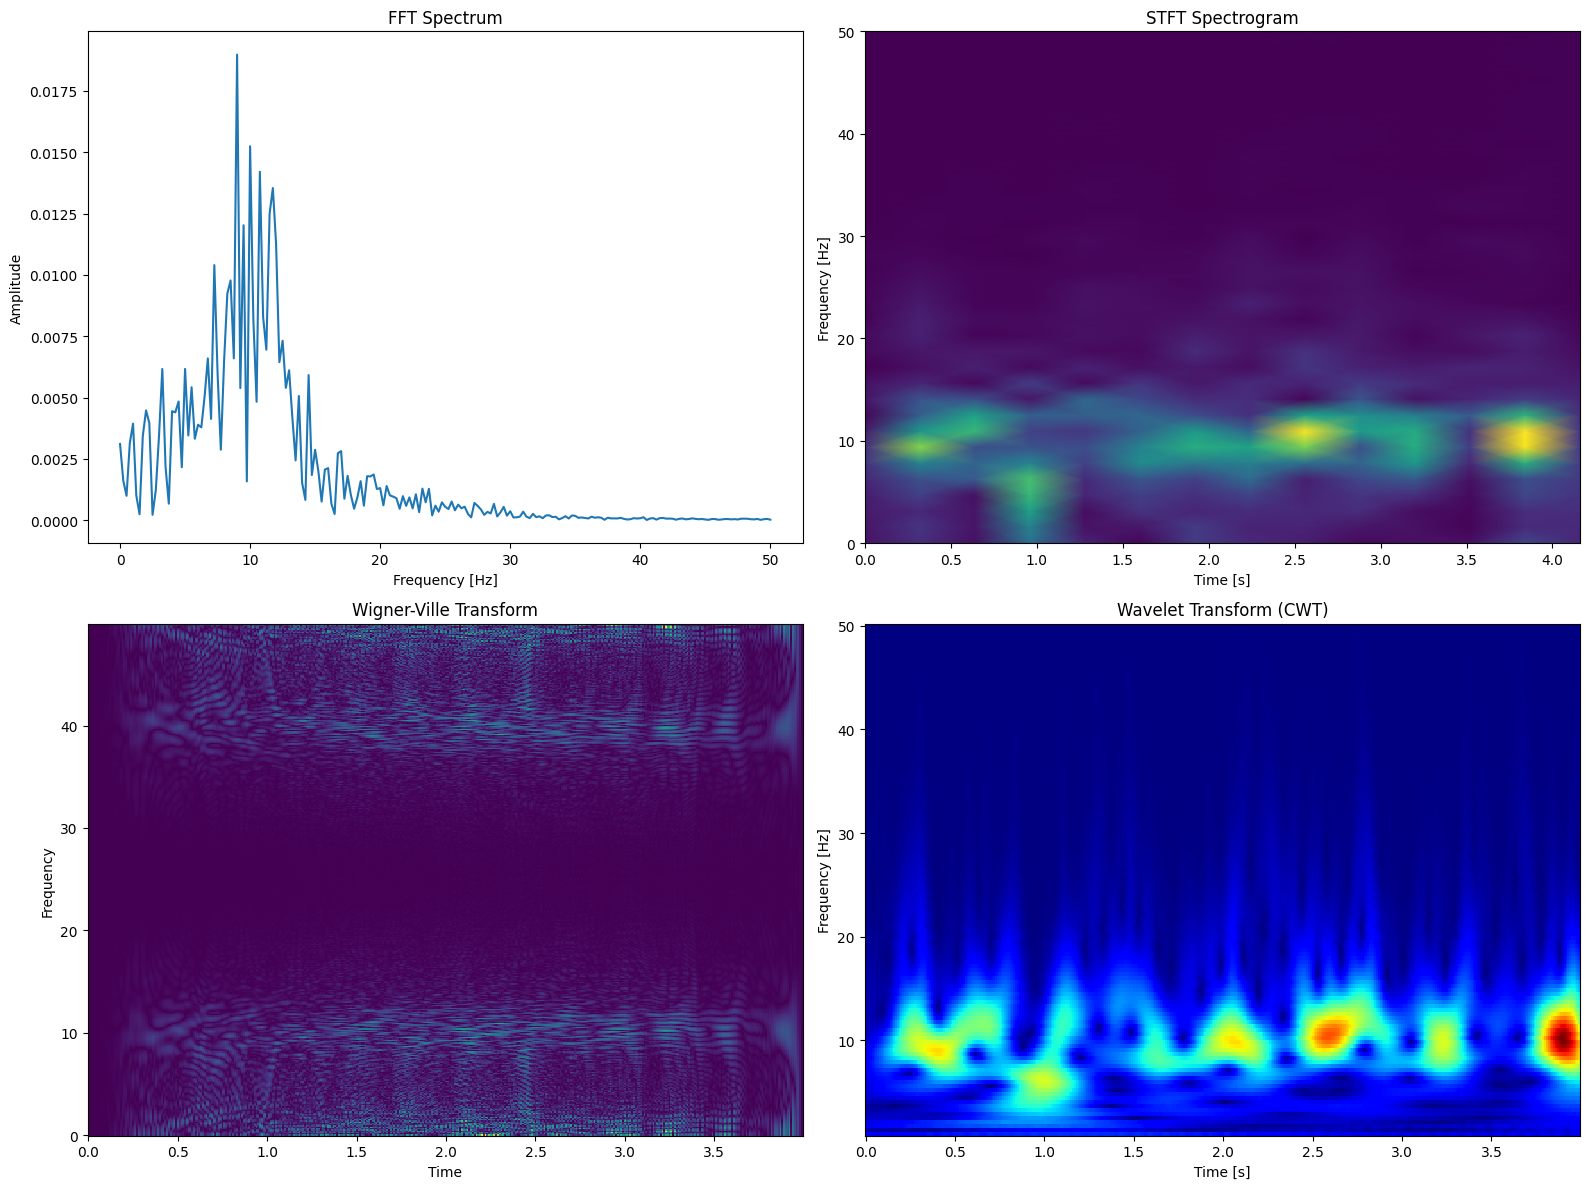

In [4]:
# ht   = SignalAnalyzer.hilbert_transform(signal, fs=100.0, n_bins=256)
analyzer = SignalAnalyzer()
window_size = 64

fft = analyzer.fft_transform(base_signal, fs=100.0)
stft = analyzer.stft_transform(base_signal, fs=100.0, nperseg=window_size)
wvt = analyzer.wvt_transform(base_signal)
cwt = analyzer.wt_transform(base_signal, fs=100.0)

results = [
    fft,
    stft,
    wvt,
    cwt
]

plot_analytical_signal = True
width = 16
height = 12
if plot_analytical_signal:
    analyzer.plot_all(base_signal, results, width, height)

## Hilbert Transform

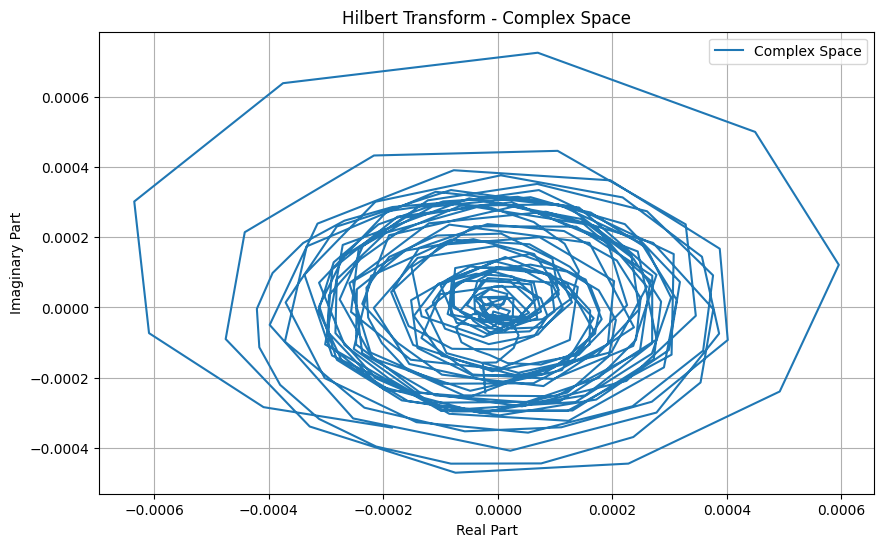

In [5]:
from scipy.signal import hilbert

# Perform Hilbert transform
hilbert_transform = hilbert(base_signal)

# Plot the complex space
plt.figure(figsize=(10, 6))
plt.plot(hilbert_transform.real, hilbert_transform.imag, label='Complex Space')
plt.title('Hilbert Transform - Complex Space')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend()
plt.grid()
plt.show()

### What do the plots tell us about the signal's stationarity?

> Given the time-varying property of the frequency magnitudes, we can conclude that the signal is non-stationary.

## Does the signal still produce the same signature even after a Gaussian component is added to the modes?

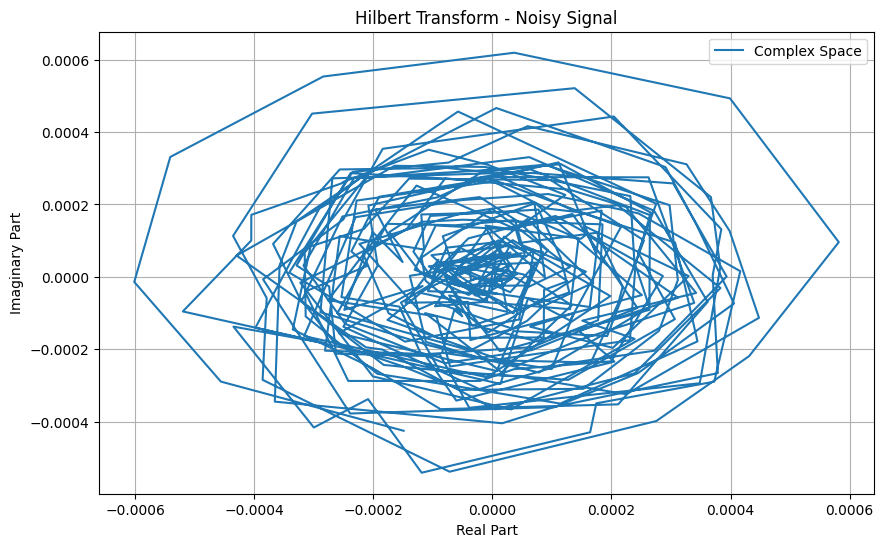

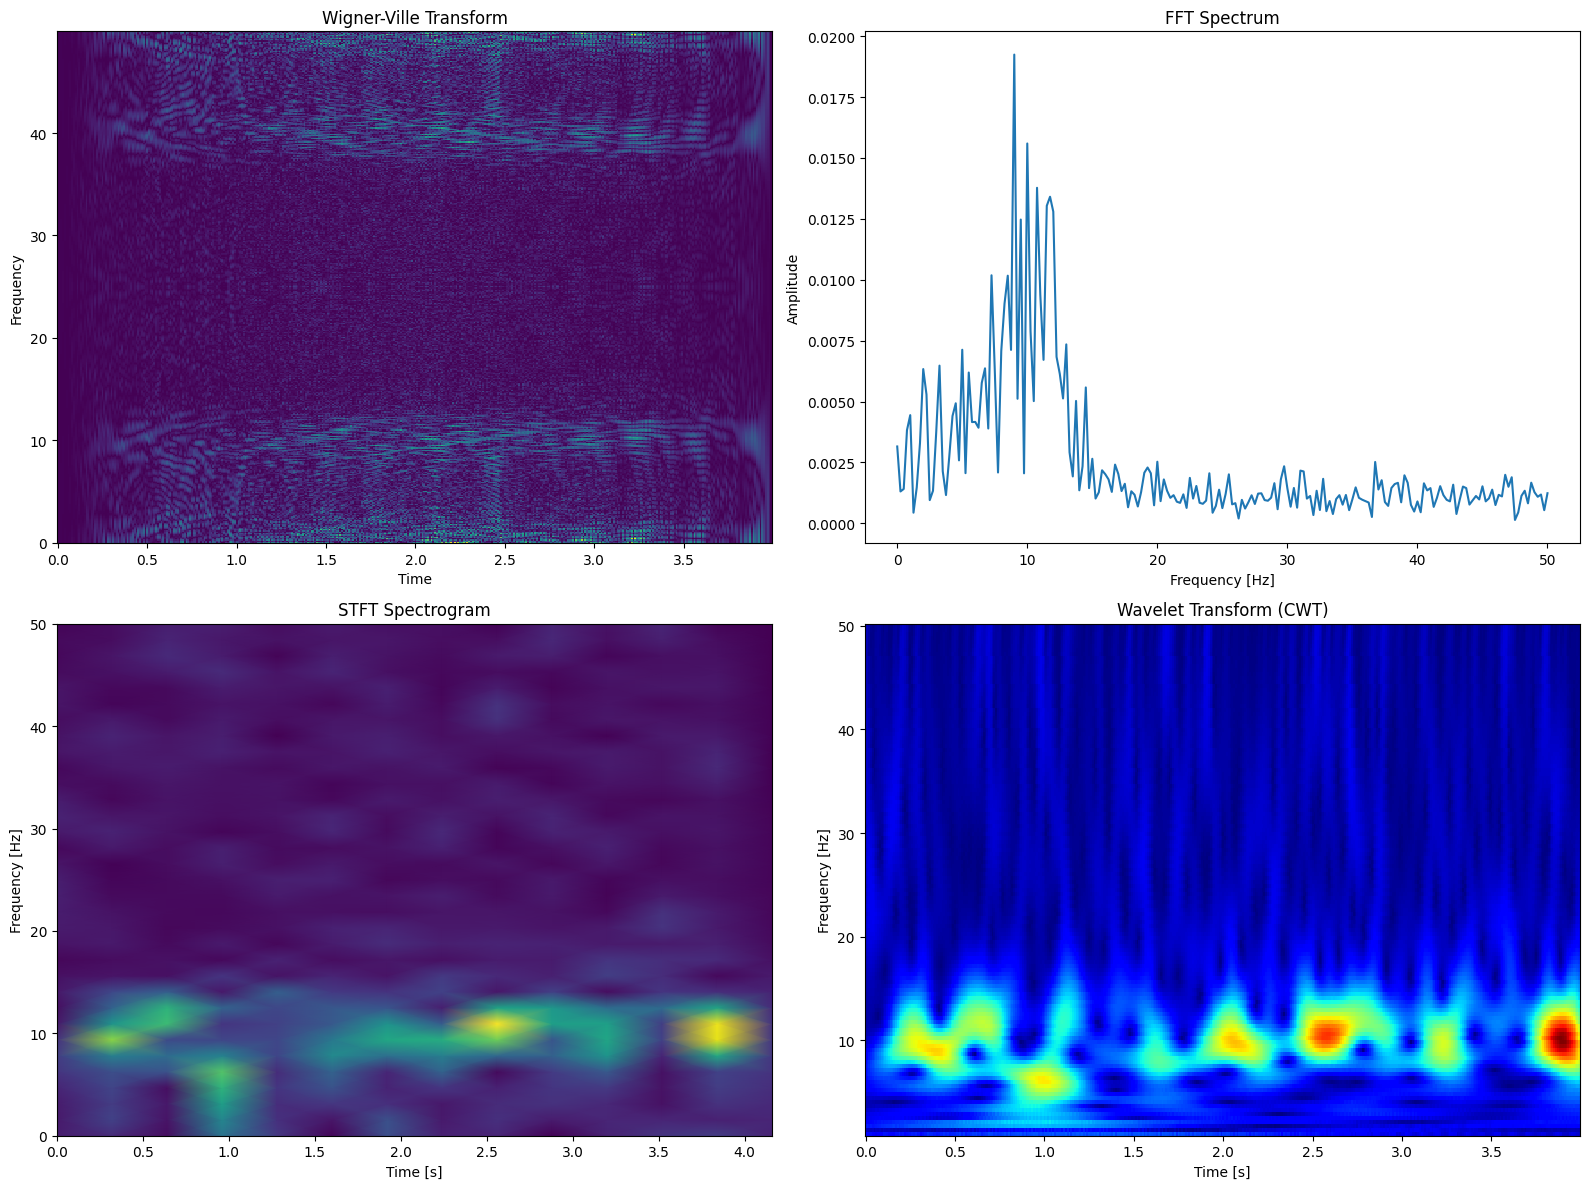

In [6]:
# Add white noise
noise = np.random.normal(0, base_signal.max() / 10, len(base_signal))
noisy_signal = base_signal + noise

# Perform Hilbert transform
hilbert_transform_noisy = hilbert(noisy_signal)

# Plot the Hilbert transform - Complex Space
plt.figure(figsize=(10, 6))
plt.plot(hilbert_transform_noisy.real, hilbert_transform_noisy.imag, label='Complex Space')
plt.title('Hilbert Transform - Noisy Signal')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.legend()
plt.grid()
plt.show()

# Perform other transformations
wvt_noisy = analyzer.wvt_transform(noisy_signal)
fft_noisy = analyzer.fft_transform(noisy_signal, fs=100.0)
stft_noisy = analyzer.stft_transform(noisy_signal, fs=100.0, nperseg=window_size)
cwt_noisy = analyzer.wt_transform(noisy_signal, wavelet='cmor1.5-1.0', fs=100.0)

results_noisy = [
    # ht_noisy,
    wvt_noisy,
    fft_noisy,
    stft_noisy,
    cwt_noisy
]
analyzer.plot_all(noisy_signal, results_noisy, width=16, height=12)


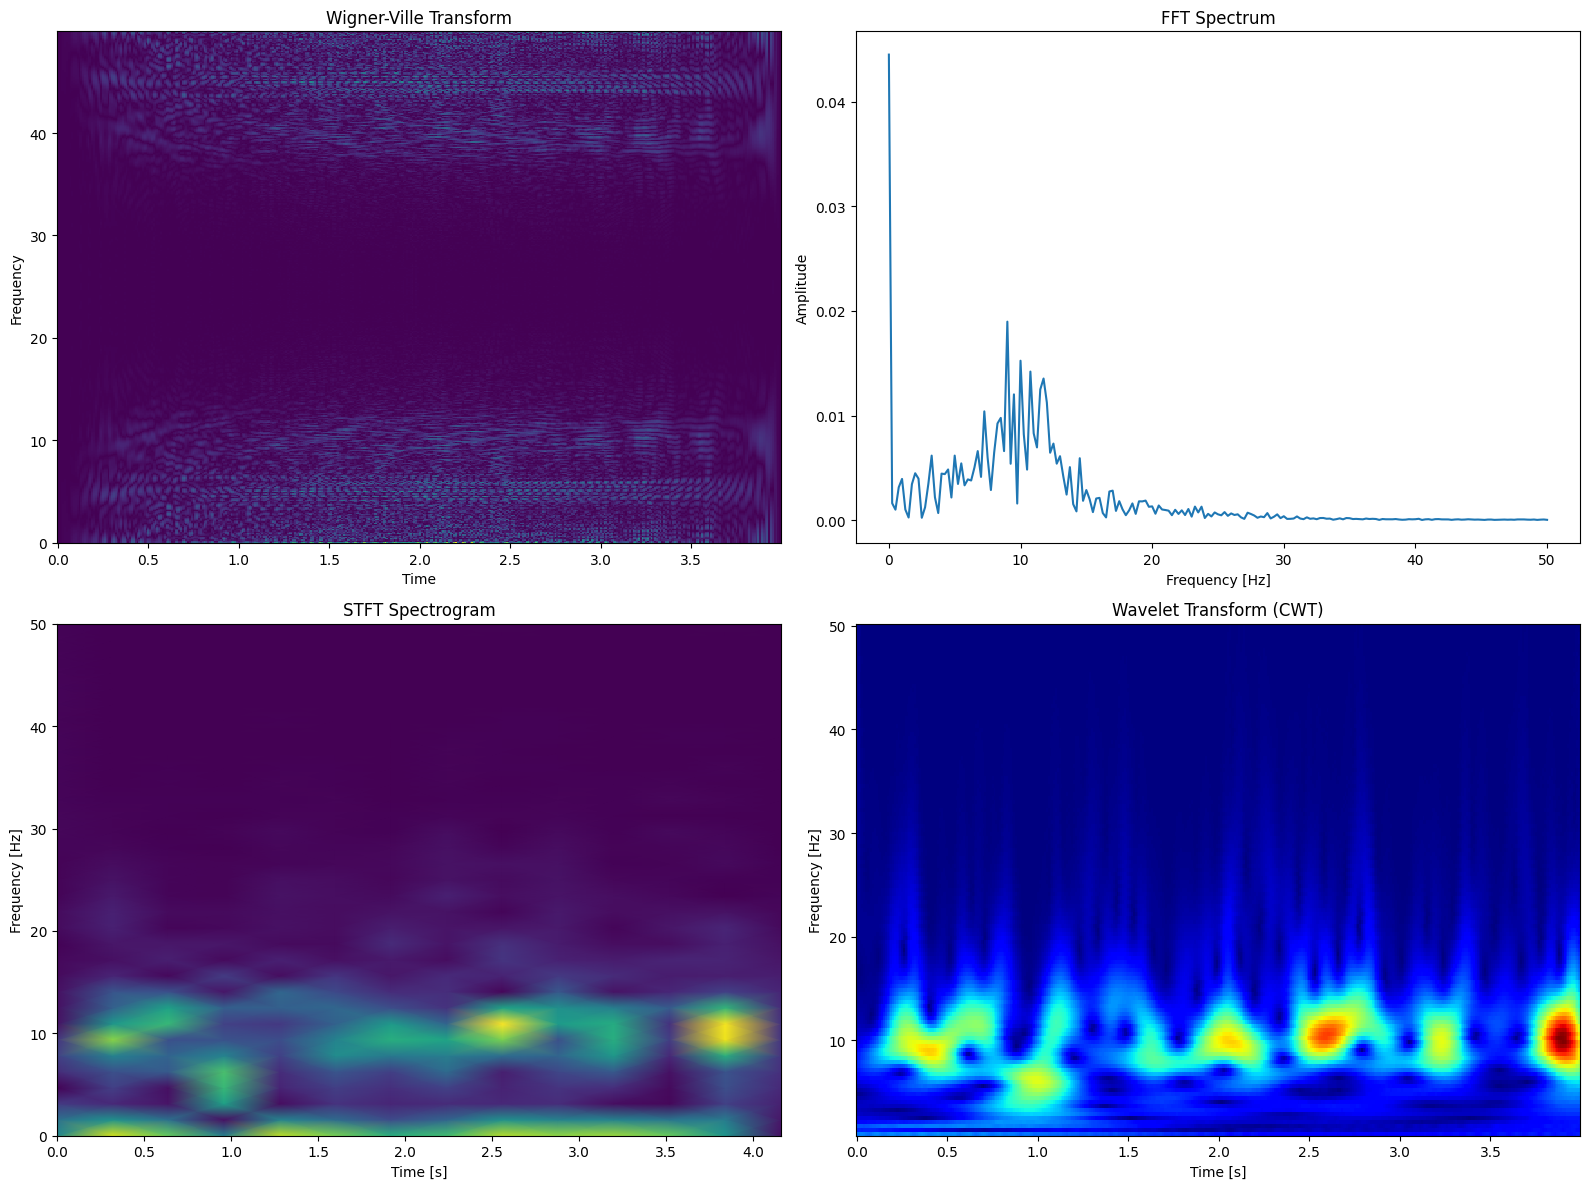

In [7]:
# add offset
offset_signal = base_signal.max()/5 + base_signal

# ht_offset   = analyzer.hilbert_transform(offset_signal, fs=100.0, n_bins=256)
wvt_offset  = analyzer.wvt_transform(offset_signal)
fft_offset  = analyzer.fft_transform(offset_signal, fs=100.0)
stft_offset = analyzer.stft_transform(offset_signal, fs=100.0, nperseg=window_size)
cwt_offset  = analyzer.wt_transform(offset_signal, wavelet='cmor1.5-1.0', fs=100.0)
results_offset = [
    # ht_offset,
    wvt_offset,
    fft_offset,
    stft_offset,
    cwt_offset
]
analyzer.plot_all(offset_signal, results_offset, width=16, height=12, spectrum=False)

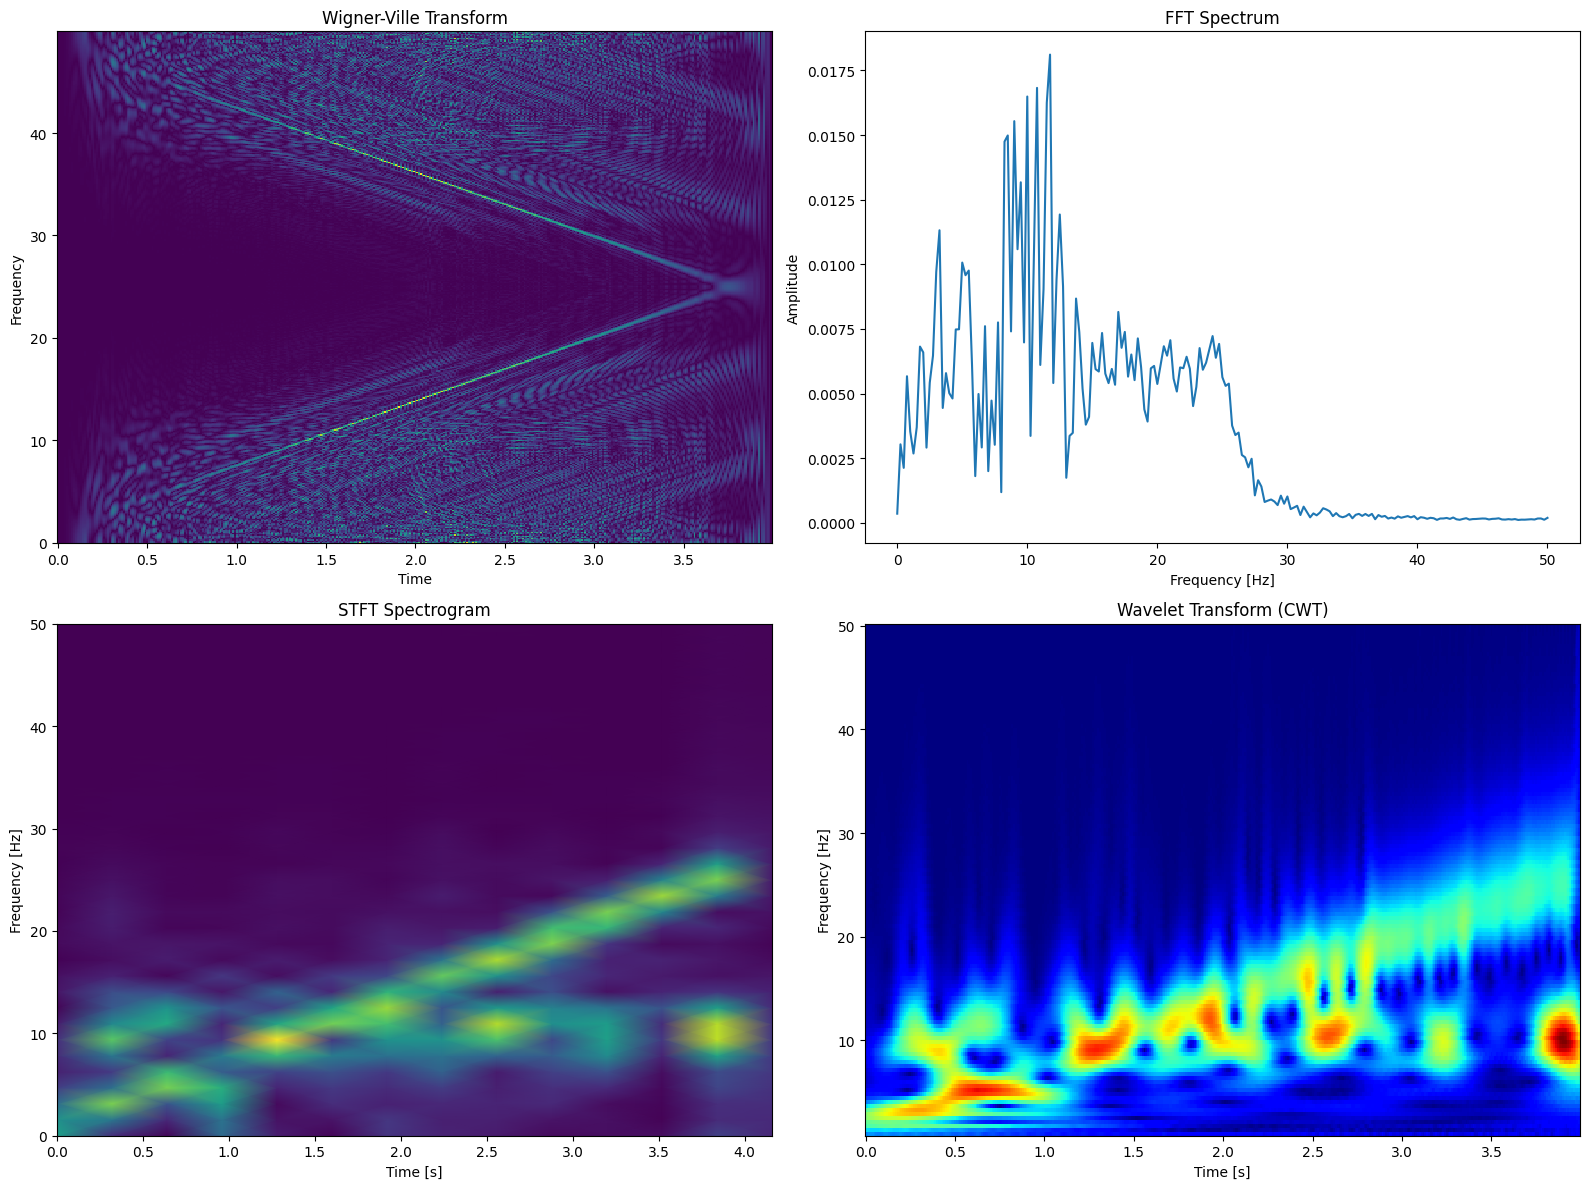

In [8]:
## Add a linearly time variying frquency component
n_chirp = len(base_signal)
t = np.linspace(0, 1, n_chirp)
k = 50 

amplitude = base_signal.max()
chirp = amplitude/2 * np.sin(2 * np.pi * (5 * t + k * t**2)) 

signal_kt = base_signal + chirp
# ht_kt   = analyzer.hilbert_transform(signal_kt, fs=100.0, n_bins=256)
wvt_kt  = analyzer.wvt_transform(signal_kt)
fft_kt  = analyzer.fft_transform(signal_kt, fs=100.0)
stft_kt = analyzer.stft_transform(signal_kt, fs=100.0, nperseg=window_size)
cwt_kt  = analyzer.wt_transform(signal_kt, wavelet='cmor1.5-1.0', fs=100.0)

results_kt = [
    # ht_kt,
    wvt_kt,
    fft_kt,
    stft_kt,
    cwt_kt
]
analyzer.plot_all(signal_kt, results_kt, width=16, height=12, spectrum=False)

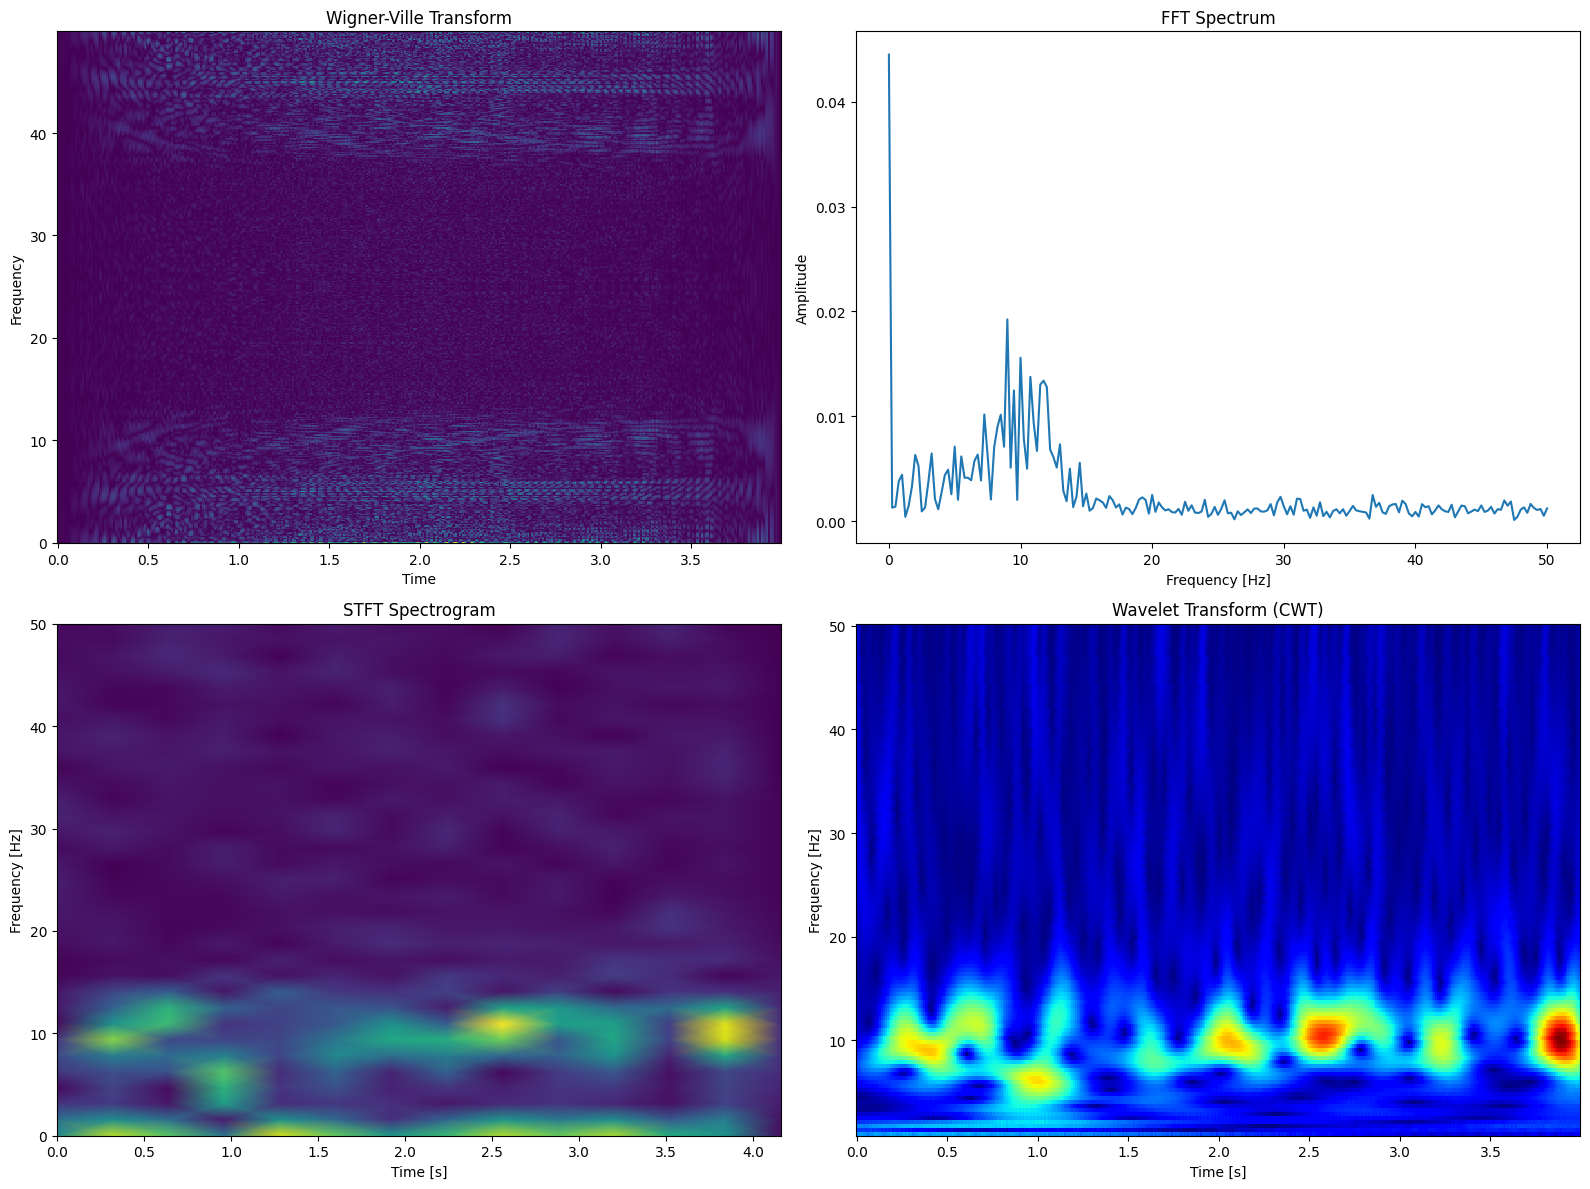

In [9]:
# offset + noise
noisy_offset_signal = offset_signal + noise
# ht_noisy_offset   = analyzer.hilbert_transform(noisy_offset_signal, fs=100.0, n_bins=128)
wvt_noisy_offset  = analyzer.wvt_transform(noisy_offset_signal)
fft_noisy_offset  = analyzer.fft_transform(noisy_offset_signal, fs=100.0)
stft_noisy_offset = analyzer.stft_transform(noisy_offset_signal, fs=100.0, nperseg=window_size)
cwt_noisy_offset  = analyzer.wt_transform(noisy_offset_signal, wavelet='cmor1.5-1.0', fs=100.0)
results_noisy_offset = [
    # ht_noisy_offset,
    wvt_noisy_offset,
    fft_noisy_offset,
    stft_noisy_offset,
    cwt_noisy_offset
]
analyzer.plot_all(noisy_offset_signal, results_noisy_offset, width=16, height=12)